In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import lick as lk
from matplotloom import Loom
from tqdm import tqdm
from joblib import Parallel, delayed
import re
import matplotlib.cm as cm
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.transforms import Bbox
import matplotlib.gridspec as gridspec

In [2]:
gconst = 6.67430e-8
clight = 2.99792458e10
solar = 1.98847e33
lencgs2code = (clight**2)/(solar*gconst)
masscgs2code = (1.0e0/solar)
rhocgs2code = (masscgs2code/lencgs2code**3)
tcgs2code = (clight**3)/(solar*gconst)
mu_0 = 1.25663706212e-6
amp2code = (mu_0*1.0e5*masscgs2code*lencgs2code)**(0.5e0)/tcgs2code
gauss2code = 1.0e-1*masscgs2code/amp2code/tcgs2code**2
energycgs2code = (1.0E0/clight**2)
me2 = 9.1093837015e-28*masscgs2code
mb2 = 1.66053906660e-24*masscgs2code
ye = 0.5e0
h_bar = (1.054571817e-27)*(lencgs2code**2*masscgs2code/tcgs2code)
amax = (me2**4)/(2.4e1*np.pi**2*h_bar**3)
bmax = (mb2*me2**3)/(3.0e0*np.pi**2*h_bar**3*ye)

In [3]:
irho = 0
ivx = 1
ivy = 2
ivz = 3
itau = 4
ihe4 = 5
ic12 = 6
io16 = 7
ine20 = 8
img24 = 9
isi28 = 10
ini56 = 11
iye2 = 12
iturbq = 13
iscaG1 = 14
iscaG2 = 15

In [4]:
def parse_cumc3d_detonations(file_path):
    times, xs, zs = [], [], []

    time_pattern = re.compile(r"Occured at\s*=\s*(?P<time>[\d\.eE\+-]+)")
    coords_pattern = re.compile(r"Found deton at\s*(?P<x>\d+)\s+(?P<z>\d+)")

    current_time = None

    with open(file_path, "r") as f:
        for line in f:
            cleaned = line.strip()

            # Catch the detonation timestamp
            time_match = time_pattern.search(cleaned)
            if time_match:
                current_time = float(time_match.group("time"))
                continue

            # Catch the corresponding spatial grid coordinates
            coords_match = coords_pattern.search(cleaned)
            if coords_match and current_time is not None:
                times.append(current_time)
                xs.append(int(coords_match.group("x")))
                zs.append(int(coords_match.group("z")))
                current_time = None  # Reset state

    return np.array(times), np.array(xs), np.array(zs)

def map_times_to_closest_indices(detonation_times, target_time_axis):
    """Maps an array of detonation times to the closest indices of a target time axis."""
    target_time_axis = np.asarray(target_time_axis)
    detonation_times = np.asarray(detonation_times)

    # Find the insertion index where each detonation time would fall
    idx = np.searchsorted(target_time_axis, detonation_times)

    # Clip indices to safely look at [idx - 1] and [idx] without IndexError.
    # This also naturally handles edge cases where detonation times are out of bounds.
    clipped_idx = np.clip(idx, 1, len(target_time_axis) - 1)

    # Calculate distances to the time step before and the time step after
    dist_left = detonation_times - target_time_axis[clipped_idx - 1]
    dist_right = target_time_axis[clipped_idx] - detonation_times

    # If the left neighbor is closer, choose clipped_idx - 1, otherwise clipped_idx
    closest_indices = np.where(dist_left < dist_right, clipped_idx - 1, clipped_idx)

    return closest_indices


In [5]:
def read_star(working_directory):
    x1f = np.loadtxt(working_directory+'/hydro_x1_fgrid.dat')
    x1f = x1f [3:-3] # Remove BC
    x1c = (x1f[1:]+x1f[:-1])/2 #mid pt
    x3f = np.loadtxt(working_directory+'/hydro_x3_fgrid.dat')
    x3f = x3f [3:-3] # Remove BC
    x3c = (x3f[1:]+x3f[:-1])/2 #mid pt
    rho = np.loadtxt(working_directory+'/hydro_rho.dat')
    Aphi = np.loadtxt(working_directory+'/hydro_Aphi.dat')
    vphi = np.loadtxt(working_directory+'/hydro_vphi.dat')
    return x1f, x1c, x3f, x3c, rho, Aphi, vphi

def parse_path(path):
    axis_ratio = float(re.search(r'AxisRatio_([0-9.]+)', path).group(1))
    mass = float(re.search(r'mass_([0-9.]+)', path).group(1))
    return axis_ratio, mass

def find_times(path):
    files = []
    working_directory = path+'/outfile'
    for f in glob(working_directory+'/*.hdf5'):
        files.append(f)
    n = len(files)-1
    times = []
    for t in range(n):
        filename = path+"/outfile/rkiter-"+str(t)+"-nm.hdf5"
        f = h5py.File(filename, "r")
        times.append(f['time'][0]/tcgs2code)
        f.close()
    return np.array(times)
    

In [6]:
data_paths = sorted(glob("/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_runs/Output_CentralDensity_*_AxisRatio_*"))[::-1]
data_paths = sorted(data_paths, key=lambda x: (-parse_path(x)[0], parse_path(x)[1]))

In [7]:
req = np.array([2226.5435038 , 2931.45458253, 2446.35563511, 1930.79000826,
       1923.28600474, 1815.02041469, 2604.67542559, 1662.12581703,
       1620.22094116, 2983.32328168, 1790.31427217, 1812.45432216])
masses = np.array([1.37718716, 1.41225941, 1.5333452 , 1.65260647, 1.6563158 ,
       1.69271405, 1.63638974, 1.98545807, 2.03663921, 1.82438131,
       2.78735779, 2.86254625])
ratios = np.array([1.000, 0.737, 0.737, 0.737, 0.737, 0.737, 0.629, 0.629, 0.629, 0.479,0.479,0.479])

In [7]:
rotating = [0,1,2,6,9]
magnetised = [0,5,8,11]
mixed = [0,3,4,7,10]
mm = [3,4,5,7,8,10,11]
RB = [1,2,3,4,5]
B_flag = [1]*12
for index in [0,1,2,6,9]:
    B_flag[index] = 0
names = ["1.000","0.737R","0.737V","0.737RB","0.737VB","0.737B","0.629V","0.629VB","0.629B","0.479V","0.479VB","0.479B"]
# names = ["Base","R","0.737V","0.737RB","0.737VB","0.737B","0.629V","0.629VB","0.629B","V","VB","B"]
color_points = ['black', 'magenta', 'red', 'green', 'purple', 'blue', 'red', 'purple', 'blue', 'red', 'purple', 'blue']


In [12]:
data_paths.append('/home/cnchong/Codes/cumc3d/model/Type_Ia')
B_flag[0] = 1

# $\rho$

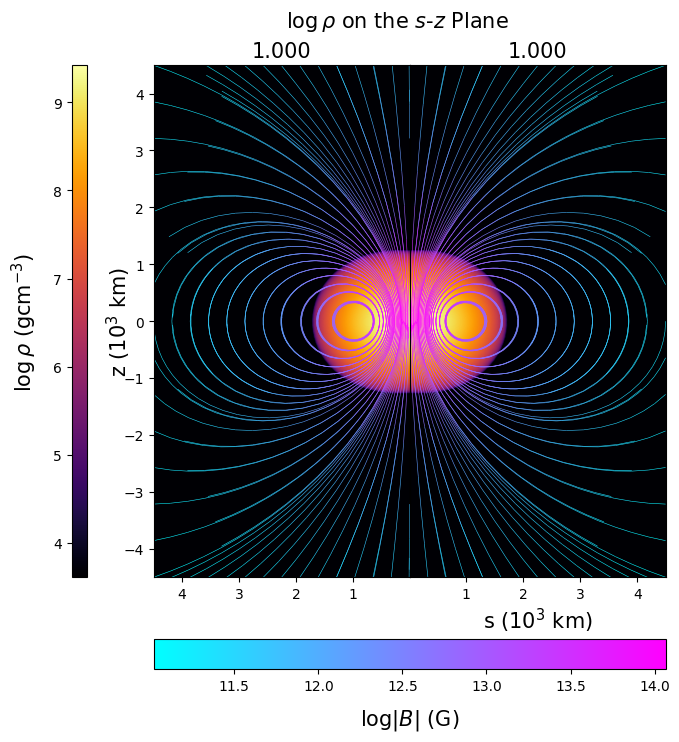

In [13]:
# --- Initialization & Data Loading ---
il = 0
ir = 0
it = 0

# Data for left plot
data_path_l = data_paths[il]
working_directory = data_path_l+'/profile'
x1f0, x1c0, x3f0, x3c0, rho0, temp, vphi = read_star(working_directory)
filename = data_path_l+"/outfile/rkiter-"+str(it)+"-nm.hdf5"
f = h5py.File(filename, "r")
primitive = f['primitive'][:].T
rho0 = primitive[0,1:-1,1,1:-1]/(rhocgs2code)
timel = f['time'][0]/tcgs2code
if B_flag[il] == 1:
    bcells = f['bcell'][:].T
    bx0 = bcells[0,1:,1,1:]/gauss2code
    bz0 = bcells[2,1:,1,1:]/gauss2code
f.close()

# Data for right plot
data_path_r = data_paths[ir]
working_directory = data_path_r+'/profile'
x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(working_directory)
filename = data_path_r+"/outfile/rkiter-"+str(it)+"-nm.hdf5"
f = h5py.File(filename, "r")
primitive = f['primitive'][:].T
rho = primitive[0,1:-1,1,1:-1]/(rhocgs2code)
timer = f['time'][0]/tcgs2code
if B_flag[ir] == 1:
    bcells = f['bcell'][:].T
    bx = bcells[0,1:,1,1:]/gauss2code
    bz = bcells[2,1:,1,1:]/gauss2code
f.close()


# ==============================================================================
# SPATIAL DETONATIONS PROCESSING FOR SPECIFIC TIMEFRAME
# ==============================================================================
# Build continuous clock tracking arrays across spatial index domains
files_l = glob(data_path_l + '/outfile/*.hdf5')
files_r = glob(data_path_r + '/outfile/*.hdf5')
n_sync = np.min([len(files_l), len(files_r)])
timesteps = list(range(0, n_sync))

times_axis_l = []
times_axis_r = []
for idx_t in timesteps:
    with h5py.File(data_path_l + f"/outfile/rkiter-{idx_t}-nm.hdf5", "r") as f_t:
        times_axis_l.append(f_t['time'][0] / tcgs2code)
    with h5py.File(data_path_r + f"/outfile/rkiter-{idx_t}-nm.hdf5", "r") as f_t:
        times_axis_r.append(f_t['time'][0] / tcgs2code)

# Load target detonation tracking data from localized log archives
det_times_l, detx_l, detz_l = parse_cumc3d_detonations(data_path_l + "/tmp.txt")
det_times_r, detx_r, detz_r = parse_cumc3d_detonations(data_path_r + "/tmp.txt")

# Scale simulation seconds and map matching frames
scaled_det_times_l = det_times_l / tcgs2code
scaled_det_times_r = det_times_r / tcgs2code
det_frame_indices_l = map_times_to_closest_indices(scaled_det_times_l, times_axis_l)
det_frame_indices_r = map_times_to_closest_indices(scaled_det_times_r, times_axis_r)


# --- Compute Global Normalization Limits ---
# 1. Density Norm (Calculated BEFORE plotting)
log_rho0 = np.log10(rho0).T
log_rho = np.log10(rho).T
rho_vmin = np.min([np.min(log_rho), np.min(log_rho0)])
rho_vmax = np.max([np.max(log_rho), np.max(log_rho0)])
rho_norm = colors.Normalize(vmin=rho_vmin, vmax=rho_vmax)

# 2. Magnetic Field Norm (Collect only active data to avoid zero-checks)
b_logs = []
if B_flag[il] == 1:
    color0 = np.log10(bx0.T**2 + bz0.T**2) / 2
    b_logs.append(color0)
if B_flag[ir] == 1:
    color = np.log10(bx.T**2 + bz.T**2) / 2
    b_logs.append(color)

if b_logs:
    b_vmin = np.min([np.min(b) for b in b_logs])
    b_vmax = np.max([np.max(b) for b in b_logs])
    b_norm = colors.Normalize(vmin=b_vmin, vmax=b_vmax)

# --- Set up Figure and Axes ---
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 8))

ax1.set_box_aspect(2)
ax2.set_box_aspect(2)

ax1.set_anchor('E')  
ax2.set_anchor('W')  
plt.subplots_adjust(wspace=0)

xx0, zz0 = np.meshgrid(x1c0*1e-8, x3c0*1e-8)
xx, zz = np.meshgrid(x1c*1e-8, x3c*1e-8)

# --- Plot Density Grids (Using the unified rho_norm) ---
pc1 = ax1.pcolormesh(xx0, zz0, log_rho0, cmap='inferno', shading='gouraud', norm=rho_norm)
pc2 = ax2.pcolormesh(xx, zz, log_rho, cmap='inferno', shading='gouraud', norm=rho_norm)


# ==============================================================================
# SPATIAL OVERLAY: SPECIFIC TIMEFRAME DETONATIONS
# ==============================================================================
# Left plot: Overlay detonations mapping strictly onto frame index 'it'
mask_l = (det_frame_indices_l == it)
if np.any(mask_l):
    plot_x_l = x1c0[detx_l[mask_l]] * 1e-8
    plot_z_l = x3c0[detz_l[mask_l]] * 1e-8
    ax1.scatter(plot_x_l, plot_z_l, color='red', edgecolor='black', s=45, zorder=10)

# Right plot: Overlay detonations mapping strictly onto frame index 'it'
mask_r = (det_frame_indices_r == it)
if np.any(mask_r):
    plot_x_r = x1c[detx_r[mask_r]] * 1e-8
    plot_z_r = x3c[detz_r[mask_r]] * 1e-8
    ax2.scatter(plot_x_r, plot_z_r, color='red', edgecolor='black', s=45, zorder=10)


ax2.set_xlabel(r's (10$^3$ km)', fontsize=15)
ax1.set_ylabel(r'z (10$^3$ km)', fontsize=15, labelpad=-7)
ax1.xaxis.get_major_ticks()[0].label1.set_visible(False)
ax2.yaxis.set_visible(False)

ax2.set_title(names[ir], fontsize=15)
ax1.set_title(names[il], fontsize=15)

# --- Set Coordinate Limits ---
xmax = np.min([np.max(xx), np.max(xx0)])
xmin = np.max([np.min(xx), np.min(xx0)])
zmax = np.min([np.max(zz), np.max(zz0)])
zmin = np.max([np.min(zz), np.min(zz0)])

ax1.set_xlim(xmin, xmax)
ax2.set_xlim(xmin, xmax)
ax1.set_ylim(zmin, zmax)
ax2.set_ylim(zmin, zmax)
ax1.invert_xaxis()

# --- Left Colorbar (Density) ---
cax1 = inset_axes(ax1, width="6%", height="100%", loc="lower left",
                  bbox_to_anchor=(-0.32, 0, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
cb1 = fig.colorbar(pc1, cax=cax1, ticklocation='left') 
cb1.set_label(r"$\log \rho$ (gcm$^{-3}$)", fontsize=15, labelpad=10)

# --- Streamplots ---
if B_flag[il] == 1:
    ax1.streamplot(xx0, zz0, bx0.T, bz0.T, color=color0, cmap='cool', norm=b_norm, 
                   broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')

if B_flag[ir] == 1:
    ax2.streamplot(xx, zz, bx.T, bz.T, color=color, cmap='cool', norm=b_norm, 
                   broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')

# --- Bottom Colorbar (Magnetic Field) ---
if B_flag[il] == 1 or B_flag[ir] == 1:
    cax3 = inset_axes(ax1, width="200%", height="6%", loc="lower left",
                      bbox_to_anchor=(0, -0.18, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
    
    sm = cm.ScalarMappable(cmap='cool', norm=b_norm)
    sm.set_array([])
    cb3 = fig.colorbar(sm, cax=cax3, orientation="horizontal")
    cb3.set_label(r'$\log|B|$ (G)', fontsize=15, labelpad=10)

plt.suptitle(r'$\log \rho$ on the $s$-$z$ Plane', x=0.5, y=0.95, fontsize=15)

# Lift subplots up to accommodate the bottom colorbar
plt.subplots_adjust(bottom=0.24, wspace=0)

# plt.savefig("/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_presentation/0.479VB.pdf", transparent = True)

In [21]:
names

['1.000',
 '0.737R',
 '0.737V',
 '0.737RB',
 '0.737VB',
 '0.737B',
 '0.629V',
 '0.629VB',
 '0.629B',
 '0.479V',
 '0.479VB',
 '0.479B']

In [42]:
# ==============================================================================
# 1. INITIALIZATION & STATIC MESH LOADING
# ==============================================================================
il = 7
ir = 8

# Extract static mesh coordinates and match synchronized timeline limits
data_path_l = data_paths[il]
working_directory_l = data_path_l + '/profile'
x1f0, x1c0, x3f0, x3c0, _, _, _ = read_star(working_directory_l)

working_directory_l_out = data_path_l + '/outfile'
files_l = glob(working_directory_l_out + '/*.hdf5')
nl = len(files_l)

data_path_r = data_paths[ir]
working_directory_r = data_path_r + '/profile'
x1f, x1c, x3f, x3c, _, _, _ = read_star(working_directory_r)

working_directory_r_out = data_path_r + '/outfile'
files_r = glob(working_directory_r_out + '/*.hdf5')
nr = len(files_r)

n_sync = np.min([nr, nl])
timesteps = list(range(0, n_sync))

xx0, zz0 = np.meshgrid(x1c0 * 1e-8, x3c0 * 1e-8)
xx, zz = np.meshgrid(x1c * 1e-8, x3c * 1e-8)

xmax = np.min([np.max(xx), np.max(xx0)])
xmin = np.max([np.min(xx), np.min(xx0)])
zmax = np.min([np.max(zz), np.max(zz0)])
zmin = np.max([np.min(zz), np.min(zz0)])


# ==============================================================================
# EXTRACTION & DETONATION TIMELINE MAPPING
# ==============================================================================
times_axis_l = []
times_axis_r = []
for idx_t in timesteps:
    with h5py.File(data_path_l + f"/outfile/rkiter-{idx_t}-nm.hdf5", "r") as f0:
        times_axis_l.append(f0['time'][0] / tcgs2code)
    with h5py.File(data_path_r + f"/outfile/rkiter-{idx_t}-nm.hdf5", "r") as f:
        times_axis_r.append(f['time'][0] / tcgs2code)

# Parse detonation events from localized log files "tmp.txt"
det_times_l, detx_l, detz_l = parse_cumc3d_detonations(data_path_l + "/tmp.txt")
det_times_r, detx_r, detz_r = parse_cumc3d_detonations(data_path_r + "/tmp.txt")

scaled_det_times_l = det_times_l / tcgs2code
scaled_det_times_r = det_times_r / tcgs2code

det_frame_indices_l = map_times_to_closest_indices(scaled_det_times_l, times_axis_l)
det_frame_indices_r = map_times_to_closest_indices(scaled_det_times_r, times_axis_r)


# ==============================================================================
# 2. PRE-COMPUTE GLOBAL UNIFIED ANIMATION LIMITS (ALL TIMESTEPS)
# ==============================================================================
print("Scanning all frames to determine invariant global color scale bounds...")
global_rho_min, global_rho_max = np.inf, -np.inf
global_b_min, global_b_max = np.inf, -np.inf

for it in tqdm(timesteps, desc="Analyzing Timeline Limits"):
    # --- Scan Left Dataset ---
    filename0 = data_path_l + f"/outfile/rkiter-{it}-nm.hdf5"
    with h5py.File(filename0, "r") as f0:
        p0 = f0['primitive'][:].T
        r0 = p0[0, 1:-1, 1, 1:-1] / rhocgs2code
        log_r0 = np.log10(r0).T
        valid_r0 = log_r0[np.isfinite(log_r0)]
        if len(valid_r0) > 0:
            global_rho_min = min(global_rho_min, np.min(valid_r0))
            global_rho_max = max(global_rho_max, np.max(valid_r0))
        
        if B_flag[il] == 1:
            bc0 = f0['bcell'][:].T
            bx0 = bc0[0, 1:, 1, 1:] / gauss2code
            bz0 = bc0[2, 1:, 1, 1:] / gauss2code
            color0 = np.log10(bx0.T**2 + bz0.T**2) / 2
            valid_b0 = color0[np.isfinite(color0)]
            if len(valid_b0) > 0:
                global_b_min = min(global_b_min, np.min(valid_b0))
                global_b_max = max(global_b_max, np.max(valid_b0))

    # --- Scan Right Dataset ---
    filename = data_path_r + f"/outfile/rkiter-{it}-nm.hdf5"
    with h5py.File(filename, "r") as f:
        p = f['primitive'][:].T
        r = p[0, 1:-1, 1, 1:-1] / rhocgs2code
        log_r = np.log10(r).T
        valid_r = log_r[np.isfinite(log_r)]
        if len(valid_r) > 0:
            global_rho_min = min(global_rho_min, np.min(valid_r))
            global_rho_max = max(global_rho_max, np.max(valid_r))
        
        if B_flag[ir] == 1:
            bc = f['bcell'][:].T
            bx = bc[0, 1:, 1, 1:] / gauss2code
            bz = bc[2, 1:, 1, 1:] / gauss2code
            color = np.log10(bx.T**2 + bz.T**2) / 2
            valid_b = color[np.isfinite(color)]
            if len(valid_b) > 0:
                global_b_min = min(global_b_min, np.min(valid_b))
                global_b_max = max(global_b_max, np.max(valid_b))

# Construct locked global normalizations
rho_norm = colors.Normalize(vmin=global_rho_min, vmax=global_rho_max)
has_b = (B_flag[il] == 1 or B_flag[ir] == 1)
if has_b:
    b_norm = colors.Normalize(vmin=global_b_min, vmax=global_b_max)


# ==============================================================================
# 3. ANIMATION RENDERING LOOP VIA MATPLOTLOOM
# ==============================================================================
output_video = "/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_presentation/density_evolution.mp4"

with Loom(output_video, fps=10, overwrite=True) as loom:
    for it in tqdm(timesteps, desc="Generating Video Frames"):
        
        # --- Load Left Step Data ---
        filename0 = data_path_l + f"/outfile/rkiter-{it}-nm.hdf5"
        with h5py.File(filename0, "r") as f0:
            primitive0 = f0['primitive'][:].T
            rho0 = primitive0[0, 1:-1, 1, 1:-1] / rhocgs2code
            timel = f0['time'][0] / tcgs2code
            if B_flag[il] == 1:
                bcells0 = f0['bcell'][:].T
                bx0 = bcells0[0, 1:, 1, 1:] / gauss2code
                bz0 = bcells0[2, 1:, 1, 1:] / gauss2code

        # --- Load Right Step Data ---
        filename = data_path_r + f"/outfile/rkiter-{it}-nm.hdf5"
        with h5py.File(filename, "r") as f:
            primitive = f['primitive'][:].T
            rho = primitive[0, 1:-1, 1, 1:-1] / rhocgs2code
            timer = f['time'][0] / tcgs2code
            if B_flag[ir] == 1:
                bcells = f['bcell'][:].T
                bx = bcells[0, 1:, 1, 1:] / gauss2code
                bz = bcells[2, 1:, 1, 1:] / gauss2code

        # --- Process Mesh Textures ---
        log_rho0 = np.log10(rho0).T
        log_rho = np.log10(rho).T

        # --- Generate Streamplot Mapping Color Arrays for Current Frame ---
        if B_flag[il] == 1:
            color0 = np.log10(bx0.T**2 + bz0.T**2) / 2
        if B_flag[ir] == 1:
            color = np.log10(bx.T**2 + bz.T**2) / 2

        # ==============================================================================
        # 4. CANVAS LAYOUT GENERATION & PLOTTING 
        # ==============================================================================
        fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 8))

        ax1.set_box_aspect(2)
        ax2.set_box_aspect(2)

        ax1.set_anchor('E')  
        ax2.set_anchor('W')  
        plt.subplots_adjust(wspace=0)

        # --- Draw Raster Mesh Color Maps (Using Locked Global rho_norm) ---
        pc1 = ax1.pcolormesh(xx0, zz0, log_rho0, cmap='inferno', shading='gouraud', norm=rho_norm)
        pc2 = ax2.pcolormesh(xx, zz, log_rho, cmap='inferno', shading='gouraud', norm=rho_norm)

        # --- SPATIAL OVERLAY: SPECIFIC TIMEFRAME DETONATIONS ---
        mask_l = (det_frame_indices_l == it)
        if np.any(mask_l):
            plot_x_l = x1c0[detx_l[mask_l]] * 1e-8
            plot_z_l = x3c0[detz_l[mask_l]] * 1e-8
            ax1.scatter(plot_x_l, plot_z_l, color='red', edgecolor='black', s=45, zorder=10)

        mask_r = (det_frame_indices_r == it)
        if np.any(mask_r):
            plot_x_r = x1c[detx_r[mask_r]] * 1e-8
            plot_z_r = x3c[detz_r[mask_r]] * 1e-8
            ax2.scatter(plot_x_r, plot_z_r, color='red', edgecolor='black', s=45, zorder=10)

        # --- Formatting Labels and Titles ---
        ax1.set_xlabel(r's (10$^3$ km)', fontsize=15)
        ax2.set_xlabel(r's (10$^3$ km)', fontsize=15)
        ax1.set_ylabel(r'z (10$^3$ km)', fontsize=15, labelpad=-7)
        ax1.xaxis.get_major_ticks()[0].label1.set_visible(False)
        ax2.yaxis.set_visible(False)

        ax1.set_title(names[il] + ' at time ' + f"{timel:#.3g}" + 's', fontsize=15)
        ax2.set_title(names[ir] + ' at time ' + f"{timer:#.3g}" + 's', fontsize=15)

        # --- Set Coordinate Limits ---
        ax1.set_xlim(xmin, xmax)
        ax2.set_xlim(xmin, xmax)
        ax1.set_ylim(zmin, zmax)
        ax2.set_ylim(zmin, zmax)
        ax1.invert_xaxis()

        # --- Left Colorbar (Density) ---
        cax1 = inset_axes(ax1, width="6%", height="100%", loc="lower left",
                          bbox_to_anchor=(-0.32, 0, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
        cb1 = fig.colorbar(pc1, cax=cax1, ticklocation='left') 
        cb1.set_label(r"$\log \rho$ (gcm$^{-3}$)", fontsize=15, labelpad=10)

        # --- Streamplots (Using Locked Global b_norm) ---
        if B_flag[il] == 1:
            ax1.streamplot(xx0, zz0, bx0.T, bz0.T, color=color0, cmap='cool', norm=b_norm, 
                           broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')

        if B_flag[ir] == 1:
            ax2.streamplot(xx, zz, bx.T, bz.T, color=color, cmap='cool', norm=b_norm, 
                           broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')

        # --- Bottom Colorbar (Magnetic Field) ---
        if has_b:
            cax3 = inset_axes(ax1, width="200%", height="6%", loc="lower left",
                              bbox_to_anchor=(0, -0.18, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
            
            sm = cm.ScalarMappable(cmap='cool', norm=b_norm)
            sm.set_array([])
            cb3 = fig.colorbar(sm, cax=cax3, orientation="horizontal")
            cb3.set_label(r'$\log|B|$ (G)', fontsize=15, labelpad=10)

        plt.suptitle(r'$\log \rho$ on the $s$-$z$ Plane', x=0.5, y=0.95, fontsize=15)

        # Lift subplots up to accommodate the bottom colorbar
        plt.subplots_adjust(bottom=0.24, wspace=0)

        # Save current layout structure to Loom engine and close out workspace
        loom.save_frame(fig)
        plt.close(fig)

Scanning all frames to determine invariant global color scale bounds...


Generating Video Frames: 100%|██████████| 101/101 [00:39<00:00,  2.57it/s]


# $v_s$

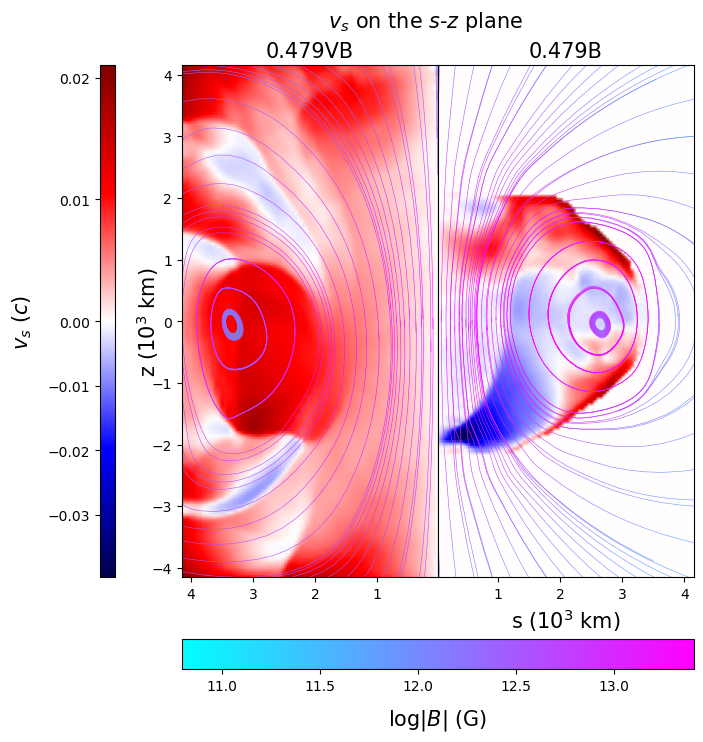

In [41]:
# --- Initialization & Data Loading ---
il = 10
ir = 11
it = 100

# Data for left plot
data_path_l = data_paths[il]
working_directory = data_path_l+'/profile'
x1f0, x1c0, x3f0, x3c0, _, temp, vphi = read_star(working_directory) # dropped unused rho0 from unpacking
filename = data_path_l+"/outfile/rkiter-"+str(it)+"-nm.hdf5"
f = h5py.File(filename, "r")
primitive = f['primitive'][:].T
vs_0 = primitive[1,1:-1,1,1:-1] # Switched to primitive[1] for v_s
timel = f['time'][0]/tcgs2code
if B_flag[il] == 1:
    bcells = f['bcell'][:].T
    bx0 = bcells[0,1:,1,1:]/gauss2code
    bz0 = bcells[2,1:,1,1:]/gauss2code
f.close()

# Data for right plot
data_path_r = data_paths[ir]
working_directory = data_path_r+'/profile'
x1f, x1c, x3f, x3c, _, temp, vphi = read_star(working_directory) # dropped unused rho from unpacking
filename = data_path_r+"/outfile/rkiter-"+str(it)+"-nm.hdf5"
f = h5py.File(filename, "r")
primitive = f['primitive'][:].T
vs = primitive[1,1:-1,1,1:-1] # Switched to primitive[1] for v_s
timer = f['time'][0]/tcgs2code
if B_flag[ir] == 1:
    bcells = f['bcell'][:].T
    bx = bcells[0,1:,1,1:]/gauss2code
    bz = bcells[2,1:,1,1:]/gauss2code
f.close()


# ==============================================================================
# SPATIAL DETONATIONS PROCESSING FOR SPECIFIC TIMEFRAME
# ==============================================================================
# Sync files to extract simulation time vectors
files_l = glob(data_path_l + '/outfile/*.hdf5')
files_r = glob(data_path_r + '/outfile/*.hdf5')
n_sync = np.min([len(files_l), len(files_r)])
timesteps = list(range(0, n_sync))

times_axis_l = []
times_axis_r = []
for idx_t in timesteps:
    with h5py.File(data_path_l + f"/outfile/rkiter-{idx_t}-nm.hdf5", "r") as f_t:
        times_axis_l.append(f_t['time'][0] / tcgs2code)
    with h5py.File(data_path_r + f"/outfile/rkiter-{idx_t}-nm.hdf5", "r") as f_t:
        times_axis_r.append(f_t['time'][0] / tcgs2code)

# Parse data out of the localized tmp.txt log files
det_times_l, detx_l, detz_l = parse_cumc3d_detonations(data_path_l + "/tmp.txt")
det_times_r, detx_r, detz_r = parse_cumc3d_detonations(data_path_r + "/tmp.txt")

# Standardize simulation code times and map onto closest frame arrays
scaled_det_times_l = det_times_l / tcgs2code
scaled_det_times_r = det_times_r / tcgs2code
det_frame_indices_l = map_times_to_closest_indices(scaled_det_times_l, times_axis_l)
det_frame_indices_r = map_times_to_closest_indices(scaled_det_times_r, times_axis_r)


# --- Compute Global Normalization Limits ---
# 1. Velocity v_s Norm (Centered at 0.0 using TwoSlopeNorm)
vs_0_mesh = vs_0.T
vs_mesh = vs.T

valid_vs_0 = vs_0_mesh[np.isfinite(vs_0_mesh)]
valid_vs = vs_mesh[np.isfinite(vs_mesh)]

vs_vmin = np.min([np.min(valid_vs), np.min(valid_vs_0)])
vs_vmax = np.max([np.max(valid_vs), np.max(valid_vs_0)])

# Ensure limits safely span across 0 for TwoSlopeNorm constraints
norm_vmin = min(vs_vmin, -1e-10)
norm_vmax = max(vs_vmax, 1e-10)
vs_norm = colors.TwoSlopeNorm(vcenter=0.0, vmin=norm_vmin, vmax=norm_vmax)

# 2. Magnetic Field Norm (Collect only active data to avoid zero-checks)
b_logs = []
if B_flag[il] == 1:
    color0 = np.log10(bx0.T**2 + bz0.T**2) / 2
    b_logs.append(color0)
if B_flag[ir] == 1:
    color = np.log10(bx.T**2 + bz.T**2) / 2
    b_logs.append(color)

if b_logs:
    b_vmin = np.min([np.min(b) for b in b_logs])
    b_vmax = np.max([np.max(b) for b in b_logs])
    b_norm = colors.Normalize(vmin=b_vmin, vmax=b_vmax)

# --- Set up Figure and Axes ---
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 8))

ax1.set_box_aspect(2)
ax2.set_box_aspect(2)

ax1.set_anchor('E')  
ax2.set_anchor('W')  
plt.subplots_adjust(wspace=0)

xx0, zz0 = np.meshgrid(x1c0*1e-8, x3c0*1e-8)
xx, zz = np.meshgrid(x1c*1e-8, x3c*1e-8)

# --- Plot Velocity Grids (Using 'seismic' and zero-centered vs_norm) ---
pc1 = ax1.pcolormesh(xx0, zz0, vs_0_mesh, cmap='seismic', shading='gouraud', norm=vs_norm)
pc2 = ax2.pcolormesh(xx, zz, vs_mesh, cmap='seismic', shading='gouraud', norm=vs_norm)


# ==============================================================================
# SPATIAL OVERLAY: SPECIFIC TIMEFRAME DETONATIONS
# ==============================================================================
# Left plot: Overlay detonations mapping strictly onto frame index 'it'
mask_l = (det_frame_indices_l == it)
if np.any(mask_l):
    plot_x_l = x1c0[detx_l[mask_l]] * 1e-8
    plot_z_l = x3c0[detz_l[mask_l]] * 1e-8
    ax1.scatter(plot_x_l, plot_z_l, color='red', edgecolor='black', s=45, zorder=10)

# Right plot: Overlay detonations mapping strictly onto frame index 'it'
mask_r = (det_frame_indices_r == it)
if np.any(mask_r):
    plot_x_r = x1c[detx_r[mask_r]] * 1e-8
    plot_z_r = x3c[detz_r[mask_r]] * 1e-8
    ax2.scatter(plot_x_r, plot_z_r, color='red', edgecolor='black', s=45, zorder=10)


ax2.set_xlabel(r's (10$^3$ km)', fontsize=15)
ax1.set_ylabel(r'z (10$^3$ km)', fontsize=15, labelpad=-7)
ax1.xaxis.get_major_ticks()[0].label1.set_visible(False)
ax2.yaxis.set_visible(False)

ax2.set_title(names[ir], fontsize=15)
ax1.set_title(names[il], fontsize=15)

# --- Set Coordinate Limits ---
xmax = np.min([np.max(xx), np.max(xx0)])
xmin = np.max([np.min(xx), np.min(xx0)])
zmax = np.min([np.max(zz), np.max(zz0)])
zmin = np.max([np.min(zz), np.min(zz0)])

ax1.set_xlim(xmin, xmax)
ax2.set_xlim(xmin, xmax)
ax1.set_ylim(zmin, zmax)
ax2.set_ylim(zmin, zmax)
ax1.invert_xaxis()

# --- Left Colorbar (Velocity v_s) ---
cax1 = inset_axes(ax1, width="6%", height="100%", loc="lower left",
                  bbox_to_anchor=(-0.32, 0, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
cb1 = fig.colorbar(pc1, cax=cax1, ticklocation='left') 
cb1.set_label(r"$v_s$ ($c$)", fontsize=15, labelpad=10)

# --- Streamplots ---
if B_flag[il] == 1:
    ax1.streamplot(xx0, zz0, bx0.T, bz0.T, color=color0, cmap='cool', norm=b_norm, 
                   broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')

if B_flag[ir] == 1:
    ax2.streamplot(xx, zz, bx.T, bz.T, color=color, cmap='cool', norm=b_norm, 
                   broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')

# --- Bottom Colorbar (Magnetic Field) ---
if B_flag[il] == 1 or B_flag[ir] == 1:
    cax3 = inset_axes(ax1, width="200%", height="6%", loc="lower left",
                      bbox_to_anchor=(0, -0.18, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
    
    sm = cm.ScalarMappable(cmap='cool', norm=b_norm)
    sm.set_array([])
    cb3 = fig.colorbar(sm, cax=cax3, orientation="horizontal")
    cb3.set_label(r'$\log|B|$ (G)', fontsize=15, labelpad=10)

plt.suptitle(r'$v_s$ on the $s$-$z$ plane', x=0.5, y=0.95, fontsize=15)

# Lift subplots up to accommodate the bottom colorbar
plt.subplots_adjust(bottom=0.24, wspace=0)

# plt.savefig("/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/CUHKthesis/figures/Most_B.pdf")

# $v_z$

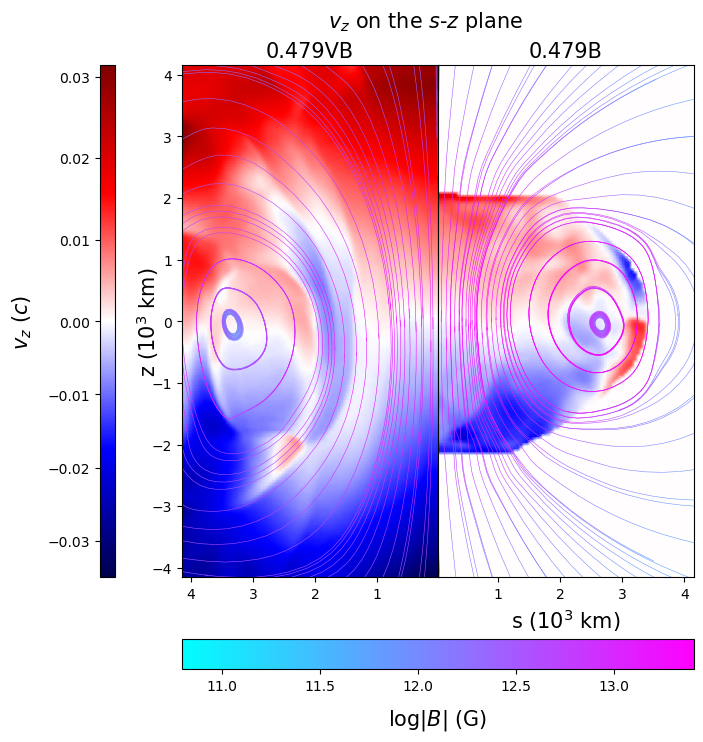

In [40]:
# --- Initialization & Data Loading ---
il = 10
ir = 11
it = 100

# Data for left plot
data_path_l = data_paths[il]
working_directory = data_path_l+'/profile'
x1f0, x1c0, x3f0, x3c0, _, temp, vphi = read_star(working_directory)
filename = data_path_l+"/outfile/rkiter-"+str(it)+"-nm.hdf5"
f = h5py.File(filename, "r")
primitive = f['primitive'][:].T
vz_0 = primitive[3,1:-1,1,1:-1] # Switched to primitive[3] for v_z
timel = f['time'][0]/tcgs2code
if B_flag[il] == 1:
    bcells = f['bcell'][:].T
    bx0 = bcells[0,1:,1,1:]/gauss2code
    bz0 = bcells[2,1:,1,1:]/gauss2code
f.close()

# Data for right plot
data_path_r = data_paths[ir]
working_directory = data_path_r+'/profile'
x1f, x1c, x3f, x3c, _, temp, vphi = read_star(working_directory)
filename = data_path_r+"/outfile/rkiter-"+str(it)+"-nm.hdf5"
f = h5py.File(filename, "r")
primitive = f['primitive'][:].T
vz = primitive[3,1:-1,1,1:-1] # Switched to primitive[3] for v_z
timer = f['time'][0]/tcgs2code
if B_flag[ir] == 1:
    bcells = f['bcell'][:].T
    bx = bcells[0,1:,1,1:]/gauss2code
    bz = bcells[2,1:,1,1:]/gauss2code
f.close()


# ==============================================================================
# SPATIAL DETONATIONS PROCESSING FOR SPECIFIC TIMEFRAME
# ==============================================================================
# Extract full simulation code-time arrays to find which hdf5 index matches the logs
files_l = glob(data_path_l + '/outfile/*.hdf5')
files_r = glob(data_path_r + '/outfile/*.hdf5')
n_sync = np.min([len(files_l), len(files_r)])
timesteps = list(range(0, n_sync))

times_axis_l = []
times_axis_r = []
for idx_t in timesteps:
    with h5py.File(data_path_l + f"/outfile/rkiter-{idx_t}-nm.hdf5", "r") as f_t:
        times_axis_l.append(f_t['time'][0] / tcgs2code)
    with h5py.File(data_path_r + f"/outfile/rkiter-{idx_t}-nm.hdf5", "r") as f_t:
        times_axis_r.append(f_t['time'][0] / tcgs2code)

# Parse full logs
det_times_l, detx_l, detz_l = parse_cumc3d_detonations(data_path_l + "/tmp.txt")
det_times_r, detx_r, detz_r = parse_cumc3d_detonations(data_path_r + "/tmp.txt")

# Scale times to code base time units and map to frame indices
scaled_det_times_l = det_times_l / tcgs2code
scaled_det_times_r = det_times_r / tcgs2code
det_frame_indices_l = map_times_to_closest_indices(scaled_det_times_l, times_axis_l)
det_frame_indices_r = map_times_to_closest_indices(scaled_det_times_r, times_axis_r)


# --- Compute Global Normalization Limits ---
# 1. Velocity v_z Norm (Centered at 0.0 using TwoSlopeNorm)
vz_0_mesh = vz_0.T
vz_mesh = vz.T

valid_vz_0 = vz_0_mesh[np.isfinite(vz_0_mesh)]
valid_vz = vz_mesh[np.isfinite(vz_mesh)]

vz_vmin = np.min([np.min(valid_vz), np.min(valid_vz_0)])
vz_vmax = np.max([np.max(valid_vz), np.max(valid_vz_0)])

# Ensure limits safely span across 0 for TwoSlopeNorm constraints
norm_vmin = min(vz_vmin, -1e-10)
norm_vmax = max(vz_vmax, 1e-10)
vz_norm = colors.TwoSlopeNorm(vcenter=0.0, vmin=norm_vmin, vmax=norm_vmax)

# 2. Magnetic Field Norm (Collect only active data to avoid zero-checks)
b_logs = []
if B_flag[il] == 1:
    color0 = np.log10(bx0.T**2 + bz0.T**2) / 2
    b_logs.append(color0)
if B_flag[ir] == 1:
    color = np.log10(bx.T**2 + bz.T**2) / 2
    b_logs.append(color)

if b_logs:
    b_vmin = np.min([np.min(b) for b in b_logs])
    b_vmax = np.max([np.max(b) for b in b_logs])
    b_norm = colors.Normalize(vmin=b_vmin, vmax=b_vmax)

# --- Set up Figure and Axes ---
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 8))

ax1.set_box_aspect(2)
ax2.set_box_aspect(2)

ax1.set_anchor('E')  
ax2.set_anchor('W')  
plt.subplots_adjust(wspace=0)

xx0, zz0 = np.meshgrid(x1c0*1e-8, x3c0*1e-8)
xx, zz = np.meshgrid(x1c*1e-8, x3c*1e-8)

# --- Plot Velocity Grids (Using 'seismic' and zero-centered vz_norm) ---
pc1 = ax1.pcolormesh(xx0, zz0, vz_0_mesh, cmap='seismic', shading='gouraud', norm=vz_norm)
pc2 = ax2.pcolormesh(xx, zz, vz_mesh, cmap='seismic', shading='gouraud', norm=vz_norm)


# ==============================================================================
# SPATIAL OVERLAY: SPECIFIC TIMEFRAME DETONATIONS
# ==============================================================================
# Check for left dataset dots happening exactly on frame 'it'
mask_l = (det_frame_indices_l == it)
if np.any(mask_l):
    plot_x_l = x1c0[detx_l[mask_l]] * 1e-8
    plot_z_l = x3c0[detz_l[mask_l]] * 1e-8
    ax1.scatter(plot_x_l, plot_z_l, color='red', edgecolor='black', s=45, zorder=10)

# Check for right dataset dots happening exactly on frame 'it'
mask_r = (det_frame_indices_r == it)
if np.any(mask_r):
    plot_x_r = x1c[detx_r[mask_r]] * 1e-8
    plot_z_r = x3c[detz_r[mask_r]] * 1e-8
    ax2.scatter(plot_x_r, plot_z_r, color='red', edgecolor='black', s=45, zorder=10)


ax2.set_xlabel(r's (10$^3$ km)', fontsize=15)
ax1.set_ylabel(r'z (10$^3$ km)', fontsize=15, labelpad=-7)
ax1.xaxis.get_major_ticks()[0].label1.set_visible(False)
ax2.yaxis.set_visible(False)

ax2.set_title(names[ir], fontsize=15)
ax1.set_title(names[il], fontsize=15)

# --- Set Coordinate Limits ---
xmax = np.min([np.max(xx), np.max(xx0)])
xmin = np.max([np.min(xx), np.min(xx0)])
zmax = np.min([np.max(zz), np.max(zz0)])
zmin = np.max([np.min(zz), np.min(zz0)])

ax1.set_xlim(xmin, xmax)
ax2.set_xlim(xmin, xmax)
ax1.set_ylim(zmin, zmax)
ax2.set_ylim(zmin, zmax)
ax1.invert_xaxis()

# --- Left Colorbar (Velocity v_z) ---
cax1 = inset_axes(ax1, width="6%", height="100%", loc="lower left",
                  bbox_to_anchor=(-0.32, 0, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
cb1 = fig.colorbar(pc1, cax=cax1, ticklocation='left') 
cb1.set_label(r"$v_z$ ($c$)", fontsize=15, labelpad=10)

# --- Streamplots ---
if B_flag[il] == 1:
    ax1.streamplot(xx0, zz0, bx0.T, bz0.T, color=color0, cmap='cool', norm=b_norm, 
                   broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')

if B_flag[ir] == 1:
    ax2.streamplot(xx, zz, bx.T, bz.T, color=color, cmap='cool', norm=b_norm, 
                   broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')

# --- Bottom Colorbar (Magnetic Field) ---
if B_flag[il] == 1 or B_flag[ir] == 1:
    cax3 = inset_axes(ax1, width="200%", height="6%", loc="lower left",
                      bbox_to_anchor=(0, -0.18, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
    
    sm = cm.ScalarMappable(cmap='cool', norm=b_norm)
    sm.set_array([])
    cb3 = fig.colorbar(sm, cax=cax3, orientation="horizontal")
    cb3.set_label(r'$\log|B|$ (G)', fontsize=15, labelpad=10)

plt.suptitle(r'$v_z$ on the $s$-$z$ plane', x=0.5, y=0.95, fontsize=15)

# Lift subplots up to accommodate the bottom colorbar
plt.subplots_adjust(bottom=0.24, wspace=0)

# plt.savefig("/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/CUHKthesis/figures/Most_B.pdf")

# Plot for $\rho,v_s,v_z$ at each time

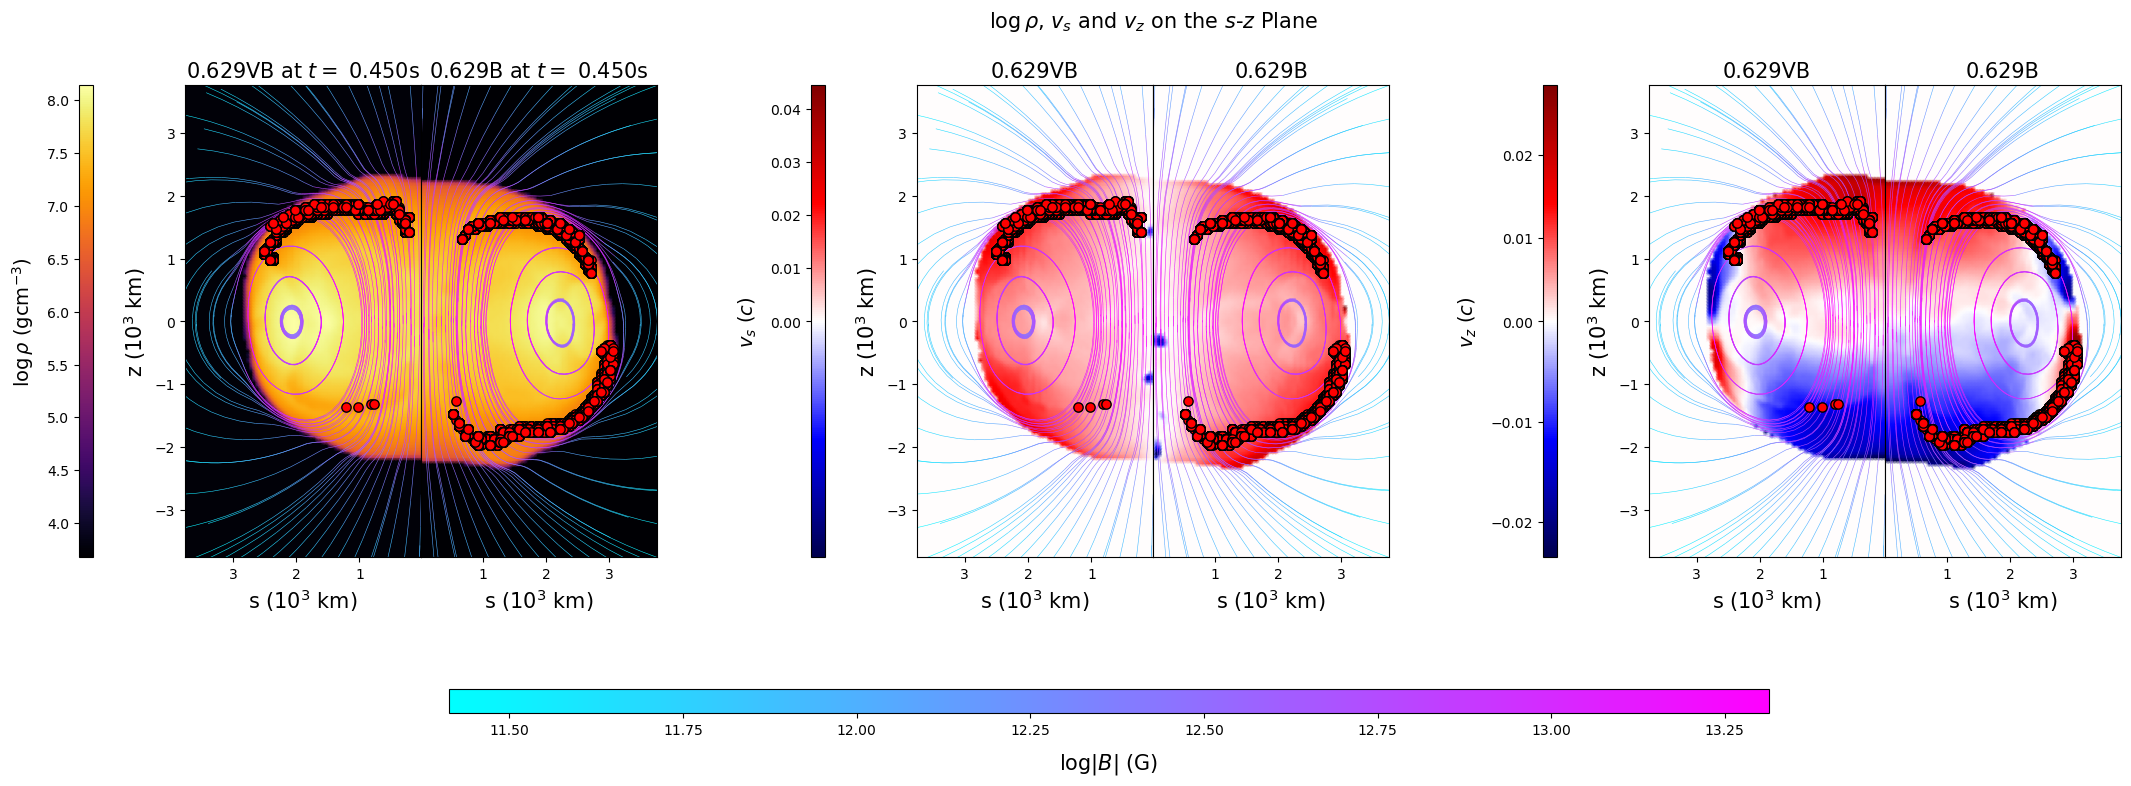

In [41]:
# ==============================================================================
# 1. INITIALIZATION & TARGET SELECTION
# ==============================================================================
il = 7
ir = 8
it = 30  # <--- CHANGE THIS VALUE DIRECTLY FOR DESIRED TARGET FRAME

# Extract static mesh coordinates and match synchronized timeline limits
data_path_l = data_paths[il]
working_directory_l = data_path_l + '/profile'
x1f0, x1c0, x3f0, x3c0, _, _, _ = read_star(working_directory_l)

working_directory_l_out = data_path_l + '/outfile'
files_l = glob(working_directory_l_out + '/*.hdf5')
nl = len(files_l)

data_path_r = data_paths[ir]
working_directory_r = data_path_r + '/profile'
x1f, x1c, x3f, x3c, _, _, _ = read_star(working_directory_r)

working_directory_r_out = data_path_r + '/outfile'
files_r = glob(working_directory_r_out + '/*.hdf5')
nr = len(files_r)

n_sync = np.min([nr, nl])
timesteps = list(range(0, n_sync))

xx0, zz0 = np.meshgrid(x1c0 * 1e-8, x3c0 * 1e-8)
xx, zz = np.meshgrid(x1c * 1e-8, x3c * 1e-8)

xmax = np.min([np.max(xx), np.max(xx0)])
xmin = np.max([np.min(xx), np.min(xx0)])
zmax = np.min([np.max(zz), np.max(zz0)])
zmin = np.max([np.min(zz), np.min(zz0)])


# ==============================================================================
# EXTRACTION & DETONATION TIMELINE MAPPING
# ==============================================================================
# Generate simulation clock maps needed to index detonation points correctly
times_axis_l = []
times_axis_r = []
for idx_t in timesteps:
    with h5py.File(data_path_l + f"/outfile/rkiter-{idx_t}-nm.hdf5", "r") as f0:
        times_axis_l.append(f0['time'][0] / tcgs2code)
    with h5py.File(data_path_r + f"/outfile/rkiter-{idx_t}-nm.hdf5", "r") as f:
        times_axis_r.append(f['time'][0] / tcgs2code)

# Parse detonation events from localized log files "tmp.txt"
det_times_l, detx_l, detz_l = parse_cumc3d_detonations(data_path_l + "/tmp.txt")
det_times_r, detx_r, detz_r = parse_cumc3d_detonations(data_path_r + "/tmp.txt")

scaled_det_times_l = det_times_l / tcgs2code
scaled_det_times_r = det_times_r / tcgs2code

det_frame_indices_l = map_times_to_closest_indices(scaled_det_times_l, times_axis_l)
det_frame_indices_r = map_times_to_closest_indices(scaled_det_times_r, times_axis_r)


# ==============================================================================
# 2. DATA LOADING FOR SPECIFIC STEP "it"
# ==============================================================================
# --- Load Left Step Data ---
filename0 = data_path_l + f"/outfile/rkiter-{it}-nm.hdf5"
with h5py.File(filename0, "r") as f0:
    primitive0 = f0['primitive'][:].T
    rho0 = primitive0[0, 1:-1, 1, 1:-1] / rhocgs2code
    vs_0 = primitive0[1, 1:-1, 1, 1:-1]
    vz_0 = primitive0[3, 1:-1, 1, 1:-1]
    timel = f0['time'][0] / tcgs2code
    if B_flag[il] == 1:
        bcells0 = f0['bcell'][:].T
        bx0 = bcells0[0, 1:, 1, 1:] / gauss2code
        bz0 = bcells0[2, 1:, 1, 1:] / gauss2code

# --- Load Right Step Data ---
filename = data_path_r + f"/outfile/rkiter-{it}-nm.hdf5"
with h5py.File(filename, "r") as f:
    primitive = f['primitive'][:].T
    rho = primitive[0, 1:-1, 1, 1:-1] / rhocgs2code
    vs = primitive[1, 1:-1, 1, 1:-1]
    vz = primitive[3, 1:-1, 1, 1:-1]
    timer = f['time'][0] / tcgs2code
    if B_flag[ir] == 1:
        bcells = f['bcell'][:].T
        bx = bcells[0, 1:, 1, 1:] / gauss2code
        bz = bcells[2, 1:, 1, 1:] / gauss2code

# --- Process Mesh Textures ---
log_rho0 = np.log10(rho0).T
log_rho = np.log10(rho).T
vs_0_mesh = vs_0.T
vs_mesh = vs.T
vz_0_mesh = vz_0.T
vz_mesh = vz.T


# ==============================================================================
# 3. CALCULATE LOCAL SCALE LIMITS SPECIFIC TO THIS FRAME
# ==============================================================================
# 1. Density Bounds
valid_rho0 = log_rho0[np.isfinite(log_rho0)]
valid_rho = log_rho[np.isfinite(log_rho)]
rho_vmin = np.min([np.min(valid_rho), np.min(valid_rho0)])
rho_vmax = np.max([np.max(valid_rho), np.max(valid_rho0)])
rho_norm = colors.Normalize(vmin=rho_vmin, vmax=rho_vmax)

# 2. Radial Velocity (v_s) Bounds
valid_vs0 = vs_0_mesh[np.isfinite(vs_0_mesh)]
valid_vs = vs_mesh[np.isfinite(vs_mesh)]
vs_vmin = np.min([np.min(valid_vs), np.min(valid_vs0)])
vs_vmax = np.max([np.max(valid_vs), np.max(valid_vs0)])
vs_norm = colors.TwoSlopeNorm(vcenter=0.0, vmin=min(vs_vmin, -1e-10), vmax=max(vs_vmax, 1e-10))

# 3. Vertical Velocity (v_z) Bounds
valid_vz0 = vz_0_mesh[np.isfinite(vz_0_mesh)]
valid_vz = vz_mesh[np.isfinite(vz_mesh)]
vz_vmin = np.min([np.min(valid_vz), np.min(valid_vz0)])
vz_vmax = np.max([np.max(valid_vz), np.max(valid_vz0)])
vz_norm = colors.TwoSlopeNorm(vcenter=0.0, vmin=min(vz_vmin, -1e-10), vmax=max(vz_vmax, 1e-10))

# 4. Magnetic Field Bounds
b_logs = []
if B_flag[il] == 1:
    color0 = np.log10(bx0.T**2 + bz0.T**2) / 2
    b_logs.append(color0)
if B_flag[ir] == 1:
    color = np.log10(bx.T**2 + bz.T**2) / 2
    b_logs.append(color)

has_b = len(b_logs) > 0
if has_b:
    b_vmin = np.min([np.min(b) for b in b_logs])
    b_vmax = np.max([np.max(b) for b in b_logs])
    b_norm = colors.Normalize(vmin=b_vmin, vmax=b_vmax)


# ==============================================================================
# 4. CANVAS LAYOUT GENERATION & PLOTTING
# ==============================================================================
fig = plt.figure(figsize=(22, 8))
gs_master = gridspec.GridSpec(1, 3, wspace=0.55, left=0.08, right=0.96, bottom=0.22, top=0.92)

gs_rho = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_master[0], wspace=0)
gs_vs  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_master[1], wspace=0)
gs_vz  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_master[2], wspace=0)

ax1 = fig.add_subplot(gs_rho[0])
ax2 = fig.add_subplot(gs_rho[1], sharey=ax1)
ax3 = fig.add_subplot(gs_vs[0], sharey=ax1)
ax4 = fig.add_subplot(gs_vs[1], sharey=ax1)
ax5 = fig.add_subplot(gs_vz[0], sharey=ax1)
ax6 = fig.add_subplot(gs_vz[1], sharey=ax1)

axes = [ax1, ax2, ax3, ax4, ax5, ax6]
for ax in axes:
    ax.set_box_aspect(2)

ax1.set_anchor('E'); ax2.set_anchor('W')
ax3.set_anchor('E'); ax4.set_anchor('W')
ax5.set_anchor('E'); ax6.set_anchor('W')

# --- Draw Raster Mesh Color Maps ---
pc1 = ax1.pcolormesh(xx0, zz0, log_rho0, cmap='inferno', shading='gouraud', norm=rho_norm)
pc2 = ax2.pcolormesh(xx, zz, log_rho, cmap='inferno', shading='gouraud', norm=rho_norm)

pc3 = ax3.pcolormesh(xx0, zz0, vs_0_mesh, cmap='seismic', shading='gouraud', norm=vs_norm)
pc4 = ax4.pcolormesh(xx, zz, vs_mesh, cmap='seismic', shading='gouraud', norm=vs_norm)

pc5 = ax5.pcolormesh(xx0, zz0, vz_0_mesh, cmap='seismic', shading='gouraud', norm=vz_norm)
pc6 = ax6.pcolormesh(xx, zz, vz_mesh, cmap='seismic', shading='gouraud', norm=vz_norm)

# --- SPATIAL OVERLAY: DETONATIONS (STRICTLY FOR ACTIVE FRAME "it") ---
mask_l = (det_frame_indices_l == it)
if np.any(mask_l):
    plot_x_l = x1c0[detx_l[mask_l]] * 1e-8
    plot_z_l = x3c0[detz_l[mask_l]] * 1e-8
    for ax_l in [ax1, ax3, ax5]:
        ax_l.scatter(plot_x_l, plot_z_l, color='red', edgecolor='black', s=45, zorder=10)

mask_r = (det_frame_indices_r == it)
if np.any(mask_r):
    plot_x_r = x1c[detx_r[mask_r]] * 1e-8
    plot_z_r = x3c[detz_r[mask_r]] * 1e-8
    for ax_r in [ax2, ax4, ax6]:
        ax_r.scatter(plot_x_r, plot_z_r, color='red', edgecolor='black', s=45, zorder=10)

# --- Format Axes and Labels ---
for ax in axes:
    ax.set_xlabel(r's (10$^3$ km)', fontsize=15)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(zmin, zmax)

for ax in [ax2, ax4, ax6]:
    ax.yaxis.set_visible(False)

ax1.set_ylabel(r'z (10$^3$ km)', fontsize=15, labelpad=5)
ax3.set_ylabel(r'z (10$^3$ km)', fontsize=15, labelpad=5)
ax5.set_ylabel(r'z (10$^3$ km)', fontsize=15, labelpad=5)

ax1.xaxis.get_major_ticks()[0].label1.set_visible(False)
ax3.xaxis.get_major_ticks()[0].label1.set_visible(False)
ax5.xaxis.get_major_ticks()[0].label1.set_visible(False)

ax1.invert_xaxis()
ax3.invert_xaxis()
ax5.invert_xaxis()

ax1.set_title(names[il] + r' at $t=$ ' + f"{timel:#.3g}" + 's', fontsize=15)
ax2.set_title(names[ir] + r' at $t=$ ' + f"{timer:#.3g}" + 's', fontsize=15)
ax3.set_title(names[il], fontsize=15)
ax4.set_title(names[ir], fontsize=15)
ax5.set_title(names[il], fontsize=15)
ax6.set_title(names[ir], fontsize=15)

# --- Subgrid Left-Side Vertical Inset Colorbars ---
cax1 = inset_axes(ax1, width="6%", height="100%", loc="lower left",
                  bbox_to_anchor=(-0.45, 0, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
cb1 = fig.colorbar(pc1, cax=cax1, ticklocation='left')
cb1.set_label(r"$\log \rho$ (gcm$^{-3}$)", fontsize=14, labelpad=8)

cax2 = inset_axes(ax3, width="6%", height="100%", loc="lower left",
                  bbox_to_anchor=(-0.45, 0, 1, 1), bbox_transform=ax3.transAxes, borderpad=0)
cb2 = fig.colorbar(pc3, cax=cax2, ticklocation='left')
cb2.set_label(r"$v_s$ ($c$)", fontsize=14, labelpad=8)

cax3 = inset_axes(ax5, width="6%", height="100%", loc="lower left",
                  bbox_to_anchor=(-0.45, 0, 1, 1), bbox_transform=ax5.transAxes, borderpad=0)
cb3 = fig.colorbar(pc5, cax=cax3, ticklocation='left')
cb3.set_label(r"$v_z$ ($c$)", fontsize=14, labelpad=8)

# --- Magnetic Field Layering ---
if B_flag[il] == 1:
    for ax in [ax1, ax3, ax5]:
        ax.streamplot(xx0, zz0, bx0.T, bz0.T, color=color0, cmap='cool', norm=b_norm, 
                       broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')

if B_flag[ir] == 1:
    for ax in [ax2, ax4, ax6]:
        ax.streamplot(xx, zz, bx.T, bz.T, color=color, cmap='cool', norm=b_norm, 
                       broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')

# Global Bottom Colorbar for Magnetic field
if has_b:
    cax_b = fig.add_axes([0.2, 0.08, 0.6, 0.03])
    sm = cm.ScalarMappable(cmap='cool', norm=b_norm)
    sm.set_array([])
    cb_b = fig.colorbar(sm, cax=cax_b, orientation="horizontal")
    cb_b.set_label(r'$\log|B|$ (G)', fontsize=15, labelpad=10)

plt.suptitle(r'$\log \rho$, $v_s$ and $v_z$ on the $s$-$z$ Plane', x=0.52, y=0.96, fontsize=15)

# --- Save Plot Snapshot ---
# output_path = f"/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/frame_{it}.pdf"
# plt.savefig(output_path)
plt.show()

# Animation for $\rho,v_s,v_z$ with detonations

In [17]:
# ==============================================================================
# 1. INITIALIZATION & TARGET SELECTION
# ==============================================================================
il = 0
ir = 0

# PERFORMANCE OPTIMIZATION: Extracting static mesh coordinates outside the loop
data_path_l = data_paths[il]
working_directory_l = data_path_l + '/profile'
x1f0, x1c0, x3f0, x3c0, _, _, _ = read_star(working_directory_l)

working_directory_l_out = data_path_l + '/outfile'
files_l = glob(working_directory_l_out + '/*.hdf5')
nl = len(files_l)

data_path_r = data_paths[ir]
working_directory_r = data_path_r + '/profile'
x1f, x1c, x3f, x3c, _, _, _ = read_star(working_directory_r)

working_directory_r_out = data_path_r + '/outfile'
files_r = glob(working_directory_r_out + '/*.hdf5')
nr = len(files_r)

# Sync timesteps across both runs
n = np.min([nr, nl])
timesteps = list(range(0, n))

xx0, zz0 = np.meshgrid(x1c0 * 1e-8, x3c0 * 1e-8)
xx, zz = np.meshgrid(x1c * 1e-8, x3c * 1e-8)

xmax = np.min([np.max(xx), np.max(xx0)])
xmin = np.max([np.min(xx), np.min(xx0)])
zmax = np.min([np.max(zz), np.max(zz0)])
zmin = np.max([np.min(zz), np.min(zz0)])


# ==============================================================================
# EXTRACTION & TIME AXIS ALIGNMENT FOR SPATIAL DETONATIONS
# ==============================================================================
# Extract simulation continuous clock axes to match spatial outputs properly
times_axis_l = []
times_axis_r = []
for it in timesteps:
    with h5py.File(data_path_l + f"/outfile/rkiter-{it}-nm.hdf5", "r") as f0:
        times_axis_l.append(f0['time'][0] / tcgs2code)
    with h5py.File(data_path_r + f"/outfile/rkiter-{it}-nm.hdf5", "r") as f:
        times_axis_r.append(f['time'][0] / tcgs2code)

# Load raw logs (Assumes files like "tmp.txt" exist inside your data paths)
det_times_l, detx_l, detz_l = parse_cumc3d_detonations(data_path_l + "/tmp.txt")
det_times_r, detx_r, detz_r = parse_cumc3d_detonations(data_path_r + "/tmp.txt")

# Scale absolute log files times to code base time units
scaled_det_times_l = det_times_l / tcgs2code
scaled_det_times_r = det_times_r / tcgs2code

# Map detonations onto continuous frame indices
det_frame_indices_l = map_times_to_closest_indices(scaled_det_times_l, times_axis_l)
det_frame_indices_r = map_times_to_closest_indices(scaled_det_times_r, times_axis_r)


# ==============================================================================
# 2. UPFRONT PRE-SCAN FOR GLOBAL NORMALIZATION LIMITS
# ==============================================================================
print("Scanning entire dataset to freeze global scale limits...")
global_rho_min, global_rho_max = np.inf, -np.inf
global_vs_min, global_vs_max = np.inf, -np.inf
global_vz_min, global_vz_max = np.inf, -np.inf
global_b_min, global_b_max = np.inf, -np.inf
has_b = False

for it in timesteps:
    # Scan Left Panel Files
    filename0 = data_path_l + f"/outfile/rkiter-{it}-nm.hdf5"
    with h5py.File(filename0, "r") as f0:
        primitive0_f = f0['primitive'][:].T
        
        # Density bounds tracking
        rho0_f = primitive0_f[0, 1:-1, 1, 1:-1] / rhocgs2code
        log_rho0_f = np.log10(rho0_f)
        valid_rho0 = log_rho0_f[np.isfinite(log_rho0_f)]
        if valid_rho0.size > 0:
            global_rho_min = min(global_rho_min, np.min(valid_rho0))
            global_rho_max = max(global_rho_max, np.max(valid_rho0))
            
        # Velocity v_s bounds tracking
        vs0_f = primitive0_f[1, 1:-1, 1, 1:-1]
        valid_vs0 = vs0_f[np.isfinite(vs0_f)]
        if valid_vs0.size > 0:
            global_vs_min = min(global_vs_min, np.min(valid_vs0))
            global_vs_max = max(global_vs_max, np.max(valid_vs0))
            
        # Velocity v_z bounds tracking
        vz0_f = primitive0_f[3, 1:-1, 1, 1:-1]
        valid_vz0 = vz0_f[np.isfinite(vz0_f)]
        if valid_vz0.size > 0:
            global_vz_min = min(global_vz_min, np.min(valid_vz0))
            global_vz_max = max(global_vz_max, np.max(valid_vz0))
        
        # B-Field bounds tracking
        if B_flag[il] == 1:
            has_b = True
            bcells0_f = f0['bcell'][:].T
            bx0_f = bcells0_f[0, 1:, 1, 1:] / gauss2code
            bz0_f = bcells0_f[2, 1:, 1, 1:] / gauss2code
            b0_log = np.log10(bx0_f**2 + bz0_f**2) / 2
            valid_b0 = b0_log[np.isfinite(b0_log)]
            if valid_b0.size > 0:
                global_b_min = min(global_b_min, np.min(valid_b0))
                global_b_max = max(global_b_max, np.max(valid_b0))

    # Scan Right Panel Files
    filename = data_path_r + f"/outfile/rkiter-{it}-nm.hdf5"
    with h5py.File(filename, "r") as f:
        primitive_f = f['primitive'][:].T
        
        # Density bounds tracking
        rho_f = primitive_f[0, 1:-1, 1, 1:-1] / rhocgs2code
        log_rho_f = np.log10(rho_f)
        valid_rho = log_rho_f[np.isfinite(log_rho_f)]
        if valid_rho.size > 0:
            global_rho_min = min(global_rho_min, np.min(valid_rho))
            global_rho_max = max(global_rho_max, np.max(valid_rho))
            
        # Velocity v_s bounds tracking
        vs_f = primitive_f[1, 1:-1, 1, 1:-1]
        valid_vs = vs_f[np.isfinite(vs_f)]
        if valid_vs.size > 0:
            global_vs_min = min(global_vs_min, np.min(valid_vs))
            global_vs_max = max(global_vs_max, np.max(valid_vs))
            
        # Velocity v_z bounds tracking
        vz_f = primitive_f[3, 1:-1, 1, 1:-1]
        valid_vz = vz_f[np.isfinite(vz_f)]
        if valid_vz.size > 0:
            global_vz_min = min(global_vz_min, np.min(valid_vz))
            global_vz_max = max(global_vz_max, np.max(valid_vz))
        
        # B-Field bounds tracking
        if B_flag[ir] == 1:
            has_b = True
            bcells_f = f['bcell'][:].T
            bx_f = bcells_f[0, 1:, 1, 1:] / gauss2code
            bz_f = bcells_f[2, 1:, 1, 1:] / gauss2code
            b_log = np.log10(bx_f**2 + bz_f**2) / 2
            valid_b = b_log[np.isfinite(b_log)]
            if valid_b.size > 0:
                global_b_min = min(global_b_min, np.min(valid_b))
                global_b_max = max(global_b_max, np.max(valid_b))

# Lock spatial scale variations into stationary norm states
rho_norm = colors.Normalize(vmin=global_rho_min, vmax=global_rho_max)
vs_norm = colors.TwoSlopeNorm(vcenter=0.0, vmin=min(global_vs_min, -1e-10), vmax=max(global_vs_max, 1e-10))
vz_norm = colors.TwoSlopeNorm(vcenter=0.0, vmin=min(global_vz_min, -1e-10), vmax=max(global_vz_max, 1e-10))
b_norm = colors.Normalize(vmin=global_b_min, vmax=global_b_max) if has_b else None

print("Global Limits Fixed Successfully!")


# ==============================================================================
# 3. ANIMATION LOOM SETUP & TIMESTEP LOOP (SOLID BACKGROUND, HIGH-DPI)
# ==============================================================================
output_movie = "/home/cnchong/Codes/cumc3d/model/Type_Ia/movie.mp4"

loom = Loom(
    output_movie, 
    fps=10, 
    overwrite=True, 
    verbose=True, 
    savefig_kwargs={"dpi": 200}
)

with loom:
    for it in timesteps:
        
        # --- Load Left Step Data ---
        filename0 = data_path_l + f"/outfile/rkiter-{it}-nm.hdf5"
        with h5py.File(filename0, "r") as f0:
            primitive0 = f0['primitive'][:].T
            rho0 = primitive0[0, 1:-1, 1, 1:-1] / rhocgs2code
            vs_0 = primitive0[1, 1:-1, 1, 1:-1]
            vz_0 = primitive0[3, 1:-1, 1, 1:-1]
            timel = f0['time'][0] / tcgs2code
            if B_flag[il] == 1:
                bcells0 = f0['bcell'][:].T
                bx0 = bcells0[0, 1:, 1, 1:] / gauss2code
                bz0 = bcells0[2, 1:, 1, 1:] / gauss2code

        # --- Load Right Step Data ---
        filename = data_path_r + f"/outfile/rkiter-{it}-nm.hdf5"
        with h5py.File(filename, "r") as f:
            primitive = f['primitive'][:].T
            rho = primitive[0, 1:-1, 1, 1:-1] / rhocgs2code
            vs = primitive[1, 1:-1, 1, 1:-1]
            vz = primitive[3, 1:-1, 1, 1:-1]
            timer = f['time'][0] / tcgs2code
            if B_flag[ir] == 1:
                bcells = f['bcell'][:].T
                bx = bcells[0, 1:, 1, 1:] / gauss2code
                bz = bcells[2, 1:, 1, 1:] / gauss2code

        # --- Process Mesh Textures ---
        log_rho0 = np.log10(rho0).T
        log_rho = np.log10(rho).T
        vs_0_mesh = vs_0.T
        vs_mesh = vs.T
        vz_0_mesh = vz_0.T
        vz_mesh = vz.T

        # --- Setup Canvas Layout ---
        fig = plt.figure(figsize=(22, 8))
        gs_master = gridspec.GridSpec(1, 3, wspace=0.55, left=0.08, right=0.96, bottom=0.22, top=0.92)

        gs_rho = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_master[0], wspace=0)
        gs_vs  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_master[1], wspace=0)
        gs_vz  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_master[2], wspace=0)

        ax1 = fig.add_subplot(gs_rho[0])
        ax2 = fig.add_subplot(gs_rho[1], sharey=ax1)
        ax3 = fig.add_subplot(gs_vs[0], sharey=ax1)
        ax4 = fig.add_subplot(gs_vs[1], sharey=ax1)
        ax5 = fig.add_subplot(gs_vz[0], sharey=ax1)
        ax6 = fig.add_subplot(gs_vz[1], sharey=ax1)

        axes = [ax1, ax2, ax3, ax4, ax5, ax6]
        for ax in axes:
            ax.set_box_aspect(2)

        ax1.set_anchor('E'); ax2.set_anchor('W')
        ax3.set_anchor('E'); ax4.set_anchor('W')
        ax5.set_anchor('E'); ax6.set_anchor('W')

        # --- Draw Raster Grids ---
        pc1 = ax1.pcolormesh(xx0, zz0, log_rho0, cmap='inferno', shading='gouraud', norm=rho_norm)
        pc2 = ax2.pcolormesh(xx, zz, log_rho, cmap='inferno', shading='gouraud', norm=rho_norm)

        pc3 = ax3.pcolormesh(xx0, zz0, vs_0_mesh, cmap='seismic', shading='gouraud', norm=vs_norm)
        pc4 = ax4.pcolormesh(xx, zz, vs_mesh, cmap='seismic', shading='gouraud', norm=vs_norm)

        pc5 = ax5.pcolormesh(xx0, zz0, vz_0_mesh, cmap='seismic', shading='gouraud', norm=vz_norm)
        pc6 = ax6.pcolormesh(xx, zz, vz_mesh, cmap='seismic', shading='gouraud', norm=vz_norm)

        # --- SPATIAL OVERLAY: DETONATIONS (STRICTLY FOR THE ACTIVE TIME FRAME) ---
        # FIXED: Changed mask comparison logic from '<=' to '==' so points disappear after the current frame
        mask_l = (det_frame_indices_l == it)
        if np.any(mask_l):
            plot_x_l = x1c0[detx_l[mask_l]] * 1e-8
            plot_z_l = x3c0[detz_l[mask_l]] * 1e-8
            for ax_l in [ax1, ax3, ax5]:
                ax_l.scatter(plot_x_l, plot_z_l, color='red', edgecolor='black', s=45, zorder=10)

        mask_r = (det_frame_indices_r == it)
        if np.any(mask_r):
            plot_x_r = x1c[detx_r[mask_r]] * 1e-8
            plot_z_r = x3c[detz_r[mask_r]] * 1e-8
            for ax_r in [ax2, ax4, ax6]:
                ax_r.scatter(plot_x_r, plot_z_r, color='red', edgecolor='black', s=45, zorder=10)

        # --- Formatting & Structural Anchors ---
        for ax in axes:
            ax.set_xlabel(r's (10$^3$ km)', fontsize=15)
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(zmin, zmax)

        for ax in [ax2, ax4, ax6]:
            ax.yaxis.set_visible(False)

        ax1.set_ylabel(r'z (10$^3$ km)', fontsize=15, labelpad=5)
        ax3.set_ylabel(r'z (10$^3$ km)', fontsize=15, labelpad=5)
        ax5.set_ylabel(r'z (10$^3$ km)', fontsize=15, labelpad=5)

        ax1.xaxis.get_major_ticks()[0].label1.set_visible(False)
        ax3.xaxis.get_major_ticks()[0].label1.set_visible(False)
        ax5.xaxis.get_major_ticks()[0].label1.set_visible(False)

        ax1.invert_xaxis()
        ax3.invert_xaxis()
        ax5.invert_xaxis()

        # Dynamic structural title changes matched to current time frames
        ax1.set_title(names[il] + ' at time ' + f"{timel:#.3g}" + 's', fontsize=15)
        ax2.set_title(names[ir] + ' at time ' + f"{timer:#.3g}" + 's', fontsize=15)
        ax3.set_title(names[il], fontsize=15)
        ax4.set_title(names[ir], fontsize=15)
        ax5.set_title(names[il], fontsize=15)
        ax6.set_title(names[ir], fontsize=15)

        # --- Vertical Subgrid Side Inset Colorbars ---
        cax1 = inset_axes(ax1, width="6%", height="100%", loc="lower left",
                          bbox_to_anchor=(-0.45, 0, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
        cb1 = fig.colorbar(pc1, cax=cax1, ticklocation='left')
        cb1.set_label(r"$\log \rho$ (gcm$^{-3}$)", fontsize=14, labelpad=8)

        cax2 = inset_axes(ax3, width="6%", height="100%", loc="lower left",
                          bbox_to_anchor=(-0.45, 0, 1, 1), bbox_transform=ax3.transAxes, borderpad=0)
        cb2 = fig.colorbar(pc3, cax=cax2, ticklocation='left')
        cb2.set_label(r"$v_s$ ($c$)", fontsize=14, labelpad=8)

        cax3 = inset_axes(ax5, width="6%", height="100%", loc="lower left",
                          bbox_to_anchor=(-0.45, 0, 1, 1), bbox_transform=ax5.transAxes, borderpad=0)
        cb3 = fig.colorbar(pc5, cax=cax3, ticklocation='left')
        cb3.set_label(r"$v_z$ ($c$)", fontsize=14, labelpad=8)

        # --- Magnetic Vector Field Layering ---
        if B_flag[il] == 1:
            color0 = np.log10(bx0.T**2 + bz0.T**2) / 2
            for ax in [ax1, ax3, ax5]:
                ax.streamplot(xx0, zz0, bx0.T, bz0.T, color=color0, cmap='cool', norm=b_norm, 
                               broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')

        if B_flag[ir] == 1:
            color = np.log10(bx.T**2 + bz.T**2) / 2
            for ax in [ax2, ax4, ax6]:
                ax.streamplot(xx, zz, bx.T, bz.T, color=color, cmap='cool', norm=b_norm, 
                               broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')

        # Global Bottom Magnetic field Scale
        if has_b:
            cax_b = fig.add_axes([0.2, 0.08, 0.6, 0.03])
            sm = cm.ScalarMappable(cmap='cool', norm=b_norm)
            sm.set_array([])
            cb_b = fig.colorbar(sm, cax=cax_b, orientation="horizontal")
            cb_b.set_label(r'$\log|B|$ (G)', fontsize=15, labelpad=10)

        plt.suptitle(r'$\log \rho$, $v_s$ and $v_z$ on the $s$-$z$ Plane', x=0.52, y=0.96, fontsize=15)
        
        # --- Save Render & Clean Memory Stack ---
        loom.save_frame(fig)
        plt.close(fig)

Scanning entire dataset to freeze global scale limits...
Global Limits Fixed Successfully!
output_filepath: /home/cnchong/Codes/cumc3d/model/Type_Ia/movie.mp4
frames_directory: /tmp/tmpsaubsi4r
Saving frame 0 to /tmp/tmpsaubsi4r/frame_000000.png
Saving frame 1 to /tmp/tmpsaubsi4r/frame_000001.png
Saving frame 2 to /tmp/tmpsaubsi4r/frame_000002.png
Saving frame 3 to /tmp/tmpsaubsi4r/frame_000003.png
Saving frame 4 to /tmp/tmpsaubsi4r/frame_000004.png
Saving frame 5 to /tmp/tmpsaubsi4r/frame_000005.png
Saving frame 6 to /tmp/tmpsaubsi4r/frame_000006.png
Saving frame 7 to /tmp/tmpsaubsi4r/frame_000007.png
Saving frame 8 to /tmp/tmpsaubsi4r/frame_000008.png
Saving frame 9 to /tmp/tmpsaubsi4r/frame_000009.png
Saving frame 10 to /tmp/tmpsaubsi4r/frame_000010.png
Saving frame 11 to /tmp/tmpsaubsi4r/frame_000011.png
Saving frame 12 to /tmp/tmpsaubsi4r/frame_000012.png
Saving frame 13 to /tmp/tmpsaubsi4r/frame_000013.png
Saving frame 14 to /tmp/tmpsaubsi4r/frame_000014.png
Saving frame 15 to /t

# Initial scalar field plot

In [ ]:
il= 0
ir = 11
it = 0

#Data for left plot
data_path = data_paths[il]
working_directory = data_path+'/profile'
x1f0, x1c0, x3f0, x3c0, rho0, temp, vphi = read_star(working_directory)
filename = data_path+"/outfile/rkiter-"+str(it)+"-nm.hdf5"
f = h5py.File(filename, "r")
primitive = f['primitive'][:].T
rho0 = primitive[iscaG1,1:-1,1,1:-1]/(lencgs2code)
star0 = primitive[irho,1:-1,1,1:-1]/(rhocgs2code)
timel = f['time'][0]/tcgs2code
if B_flag[il] == 1:
    bcells = f['bcell'][:].T
    bx0 = bcells[0,1:,1,1:]/gauss2code
    bz0 = bcells[2,1:,1,1:]/gauss2code
f.close()


#Data for right plot
data_path = data_paths[ir]
working_directory = data_path+'/profile'
x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(working_directory)
filename = data_path+"/outfile/rkiter-"+str(it)+"-nm.hdf5"
f = h5py.File(filename, "r")
primitive = f['primitive'][:].T
rho = primitive[iscaG1,1:-1,1,1:-1]/(lencgs2code)
star = primitive[irho,1:-1,1,1:-1]/(rhocgs2code)
timer = f['time'][0]/tcgs2code
if B_flag[ir] == 1:
    bcells = f['bcell'][:].T
    bx = bcells[0,1:,1,1:]/gauss2code
    bz = bcells[2,1:,1,1:]/gauss2code

f.close()


fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 8))


ax1.set_box_aspect(2)
ax2.set_box_aspect(2)


ax1.set_anchor('E')  
ax2.set_anchor('W')  
plt.subplots_adjust(wspace=0)


xx0, zz0 = np.meshgrid(x1c0*1e-8, x3c0*1e-8)
xx, zz = np.meshgrid(x1c*1e-8, x3c*1e-8)
ax1.pcolormesh(xx0, zz0, np.log10(star0).T, cmap='grey_r', shading='gouraud')
pc1 = ax1.pcolormesh(xx0, zz0, np.log10(rho0).T, cmap='inferno', shading='gouraud')
ax2.pcolormesh(xx, zz, np.log10(star).T, cmap='grey_r', shading='gouraud')
pc2 = ax2.pcolormesh(xx, zz, np.log10(rho).T, cmap='inferno', shading='gouraud')

ax2.set_xlabel(r's (10$^3$ km)', fontsize=15)
ax1.set_ylabel(r'z (10$^3$ km)', fontsize=15, labelpad=-7)
ax1.xaxis.get_major_ticks()[0].label1.set_visible(False)
ax2.yaxis.set_visible(False)
# ax2.set_title(names[ir]+' at time '+f"{timer:#.3g}"+'s', fontsize=15)
ax2.set_title(names[ir], fontsize=15)
# ax1.set_title(names[il]+' at time '+f"{timel:#.3g}"+'s', fontsize=15)
ax1.set_title(names[il], fontsize=15)

# --- Set limits ---
xmax = np.min([np.max(xx), np.max(xx0)])
xmin = np.max([np.min(xx), np.min(xx0)])
zmax = np.min([np.max(zz), np.max(zz0)])
zmin = np.max([np.min(zz), np.min(zz0)])

ax1.set_xlim(xmin, xmax)
ax2.set_xlim(xmin, xmax)
ax1.set_ylim(zmin, zmax)
ax2.set_ylim(zmin, zmax)
ax1.invert_xaxis()


cax1 = inset_axes(ax1, width="6%", height="100%", loc="lower left",
                  bbox_to_anchor=(-0.32, 0, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
norm = colors.Normalize(vmin=np.min([np.min(rho), np.min(rho0)]), vmax=np.max([np.max(rho), np.max(rho0)]))
cb1 = fig.colorbar(pc1, cax=cax1, ticklocation='left',norm=norm)
cb1.set_label(r"$\log G$ (cm)", fontsize=15, labelpad=10)


# if B_flag[il] == 1 and B_flag[ir] == 0:
#     color0 = np.log10(bx0.T**2 + bz0.T**2) / 2
#     ax1.streamplot(xx0, zz0, bx0.T, bz0.T, color=color0, cmap='cool', broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')
#     color = 0

# if B_flag[ir] == 1 and B_flag[il] == 0:
#     color = np.log10(bx.T**2 + bz.T**2) / 2
#     ax2.streamplot(xx, zz, bx.T, bz.T, color=color, cmap='cool', broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')
#     color0 = 0

# if B_flag[il] == 1 and B_flag[ir] == 1:
#     color0 = np.log10(bx0.T**2 + bz0.T**2) / 2
#     ax1.streamplot(xx0, zz0, bx0.T, bz0.T, color=color0, cmap='cool', broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')
#     color = np.log10(bx.T**2 + bz.T**2) / 2
#     ax2.streamplot(xx, zz, bx.T, bz.T, color=color, cmap='cool', broken_streamlines=False, density=0.5, linewidth=0.4, arrowstyle='-')


# if B_flag[il] == 1 or B_flag[ir] == 1:
#     cax3 = inset_axes(ax1, width="200%", height="6%", loc="lower left",
#                       bbox_to_anchor=(0, -0.18, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
    
#     norm = colors.Normalize(vmin=np.min([np.min(color), np.min(color0)]), vmax=np.max([np.max(color), np.max(color0)])) 
#     cmap = 'cool'
#     sm = cm.ScalarMappable(cmap=cmap, norm=norm)
#     sm.set_array([])
#     cb3 = fig.colorbar(sm, cax=cax3, orientation="horizontal")
#     cb3.set_label(r'$\log|B|$ (G)', fontsize=15, labelpad=10)

plt.suptitle(r'White Dwarf on the $s$-$z$ Plane', x=0.5, y=0.95, fontsize=15)

# 1. Lift the subplots up to make room for the lower colorbar.
# This moves the plots and their attached insets together, preserving your 2:1 aspect ratio.
plt.subplots_adjust(bottom=0.24, wspace=0)

# 2. Save normally without any bbox_inches overrides.
# This completely prevents the ghost-frames from appearing.

plt.savefig("/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/CUHKthesis/figures/scaG.pdf")